# Diabetes Prediction: Full Feature Set vs Reduced Feature Set

**Research question:** How effective is diabetes prediction when using a full feature set (including lab-based HbA1c and blood glucose level) compared to a reduced feature set (only easily obtainable, non-invasive information)?

Both models predict the **same target**: `diabetes` (0 = No, 1 = Yes). Only the input features differ, making this a fair, controlled comparison.

- **Full Feature Set**: gender, age, hypertension, heart_disease, smoking_history, bmi, HbA1c_level, blood_glucose_level
- **Reduced Feature Set**: gender, age, hypertension, heart_disease, smoking_history, bmi (no lab data)

Algorithms compared: **Random Forest** and **K-Nearest Neighbors (KNN)**.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
import joblib
import os

os.makedirs("models", exist_ok=True)

## 1. Load Data

In [8]:
df = pd.read_csv('diabetes_prediction_dataset.csv')
print(df.shape)
df.head()

(100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [9]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

## 2. Quick EDA
Checking class balance before doing anything else.

diabetes
0    91500
1     8500
Name: count, dtype: int64
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


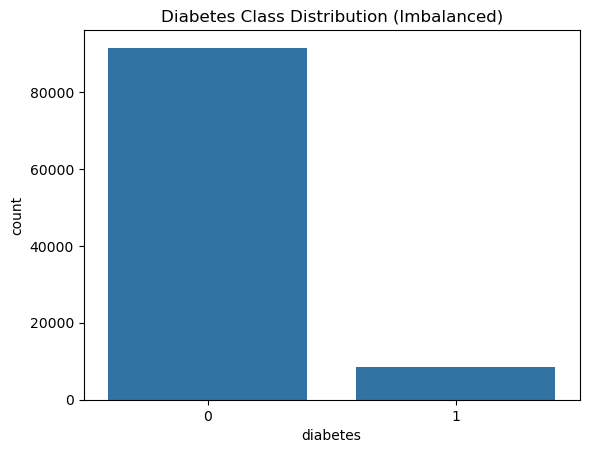

In [10]:
print(df['diabetes'].value_counts())
print(df['diabetes'].value_counts(normalize=True) * 100)

sns.countplot(x='diabetes', data=df)
plt.title("Diabetes Class Distribution (Imbalanced)")
plt.show()

## 3. Feature Engineering (Preprocessing)

Converts text columns into numbers so the model can use them, and adds a `bmi_category` feature.

In [11]:
le_gender = LabelEncoder()
le_smoking = LabelEncoder()

df['gender_enc'] = le_gender.fit_transform(df['gender'])
df['smoking_enc'] = le_smoking.fit_transform(df['smoking_history'])

print(dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
print(dict(zip(le_smoking.classes_, le_smoking.transform(le_smoking.classes_))))

{'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
{'No Info': np.int64(0), 'current': np.int64(1), 'ever': np.int64(2), 'former': np.int64(3), 'never': np.int64(4), 'not current': np.int64(5)}


In [12]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 0  # underweight
    elif bmi < 25:
        return 1  # normal
    elif bmi < 30:
        return 2  # overweight
    else:
        return 3  # obese

df['bmi_category'] = df['bmi'].apply(bmi_category)

## 4. Define Feature Sets and Target

Same target (`diabetes`) for both, same train/test split (same rows) for a fair comparison — only the columns available to the model change.

In [13]:
target = df['diabetes']

reduced_features = ['gender_enc', 'age', 'hypertension', 'heart_disease', 'smoking_enc', 'bmi', 'bmi_category']
full_features = reduced_features + ['HbA1c_level', 'blood_glucose_level']

# Same split (same rows) used for both feature sets
train_idx, test_idx = train_test_split(
    df.index, test_size=0.3, stratify=target, random_state=42
)

## 5. Train and Evaluate Function

For each feature set: scale the data, balance the training data with SMOTE (training data only), then train Random Forest and KNN.

In [14]:
def train_and_evaluate(feature_list, label):
    X = df[feature_list]
    X_train, X_test = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = target.loc[train_idx], target.loc[test_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    sm = SMOTE(random_state=42)
    X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

    algorithms = {
        "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=7),
    }

    results = {}
    trained_models = {}
    print(f"\n========== {label} ==========")
    for name, model in algorithms.items():
        model.fit(X_train_bal, y_train_bal)
        y_pred = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}
        trained_models[name] = model
        print(f"{name:15s}  Accuracy: {acc:.3f}  Precision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}")

    return results, trained_models, scaler, X_test_scaled, y_test

## 6. Run Both Comparisons

In [15]:
full_results, full_models, full_scaler, full_X_test, full_y_test = train_and_evaluate(
    full_features, "FULL FEATURE SET (with HbA1c & glucose)"
)

reduced_results, reduced_models, reduced_scaler, reduced_X_test, reduced_y_test = train_and_evaluate(
    reduced_features, "REDUCED FEATURE SET (without HbA1c & glucose)"
)


========== FULL FEATURE SET (with HbA1c & glucose) ==========
Random Forest    Accuracy: 0.927  Precision: 0.545  Recall: 0.859  F1: 0.667
KNN              Accuracy: 0.907  Precision: 0.473  Recall: 0.825  F1: 0.601

========== REDUCED FEATURE SET (without HbA1c & glucose) ==========
Random Forest    Accuracy: 0.763  Precision: 0.223  Recall: 0.719  F1: 0.341
KNN              Accuracy: 0.787  Precision: 0.210  Recall: 0.544  F1: 0.303


## 7. Comparison Table

In [16]:
comparison_rows = []
for algo in ["Random Forest", "KNN"]:
    comparison_rows.append({
        "Algorithm": algo,
        "Full - Accuracy": full_results[algo]["Accuracy"],
        "Reduced - Accuracy": reduced_results[algo]["Accuracy"],
        "Full - F1": full_results[algo]["F1"],
        "Reduced - F1": reduced_results[algo]["F1"],
        "F1 Drop": full_results[algo]["F1"] - reduced_results[algo]["F1"],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df["% F1 Drop"] = (comparison_df["F1 Drop"] / comparison_df["Full - F1"] * 100).round(1)
comparison_df

,Algorithm,Full - Accuracy,Reduced - Accuracy,Full - F1,Reduced - F1,F1 Drop,% F1 Drop
0,Random Forest,0.9271,0.763267,0.667073,0.340576,0.326497,48.9
1,KNN,0.9070,0.786933,0.601429,0.302792,0.298636,49.7


## 8. Visual Comparison

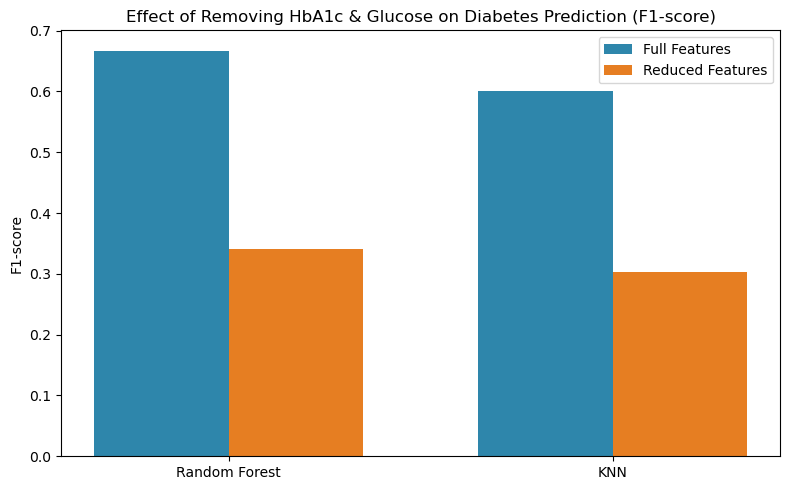

In [17]:
x = np.arange(2)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, comparison_df["Full - F1"], width, label="Full Features", color="#2E86AB")
ax.bar(x + width/2, comparison_df["Reduced - F1"], width, label="Reduced Features", color="#E67E22")
ax.set_xticks(x)
ax.set_xticklabels(comparison_df["Algorithm"])
ax.set_ylabel("F1-score")
ax.set_title("Effect of Removing HbA1c & Glucose on Diabetes Prediction (F1-score)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Confusion Matrices (Best Model: Full vs Reduced)

Best algorithm overall (by Full Feature F1): Random Forest


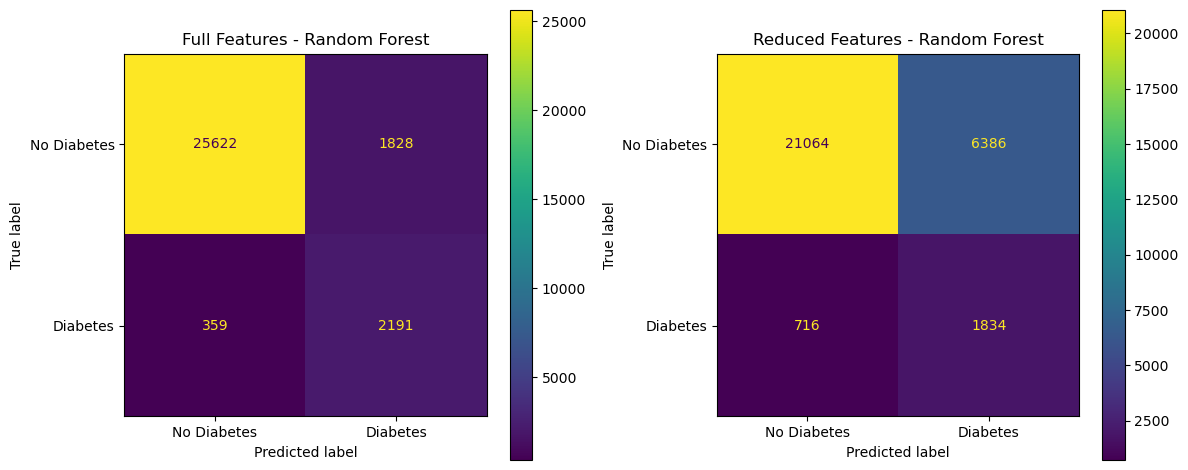

In [18]:
best_algo = comparison_df.loc[comparison_df["Full - F1"].idxmax(), "Algorithm"]
print("Best algorithm overall (by Full Feature F1):", best_algo)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_full = confusion_matrix(full_y_test, full_models[best_algo].predict(full_X_test))
ConfusionMatrixDisplay(cm_full, display_labels=["No Diabetes", "Diabetes"]).plot(ax=axes[0])
axes[0].set_title(f"Full Features - {best_algo}")

cm_reduced = confusion_matrix(reduced_y_test, reduced_models[best_algo].predict(reduced_X_test))
ConfusionMatrixDisplay(cm_reduced, display_labels=["No Diabetes", "Diabetes"]).plot(ax=axes[1])
axes[1].set_title(f"Reduced Features - {best_algo}")

plt.tight_layout()
plt.show()

## 10. Actual vs Predicted (Reduced Feature Model, Best Algorithm)

A sample of real test rows, comparing what actually happened vs what the model guessed.

In [19]:
comparison_sample = df.loc[test_idx, reduced_features].copy()
comparison_sample['Actual'] = reduced_y_test.map({0: "No Diabetes", 1: "Diabetes"})
comparison_sample['Predicted'] = pd.Series(
    reduced_models[best_algo].predict(reduced_X_test), index=test_idx
).map({0: "No Diabetes", 1: "Diabetes"})
comparison_sample['Correct?'] = comparison_sample['Actual'] == comparison_sample['Predicted']

comparison_sample.head(15)

,gender_enc,age,hypertension,heart_disease,smoking_enc,bmi,bmi_category,Actual,Predicted,Correct?
99961,1,38.00,0,0,4,27.63,2,No Diabetes,No Diabetes,True
28353,0,39.00,0,0,5,35.64,3,No Diabetes,No Diabetes,True
82494,0,34.00,0,0,5,27.32,2,No Diabetes,No Diabetes,True
78287,0,43.00,0,0,4,27.32,2,No Diabetes,No Diabetes,True
17812,0,62.00,0,0,4,37.17,3,No Diabetes,Diabetes,False
23320,0,57.00,0,0,0,33.53,3,No Diabetes,Diabetes,False
27015,0,29.00,0,0,1,38.66,3,No Diabetes,No Diabetes,True
25271,0,80.00,0,0,5,27.32,2,No Diabetes,No Diabetes,True
1774,1,67.00,1,0,3,32.04,3,No Diabetes,Diabetes,False
4808,1,49.00,0,0,2,30.42,3,No Diabetes,Diabetes,False


In [20]:
print("Out of", len(comparison_sample), "test rows:")
print("Correct predictions:", comparison_sample['Correct?'].sum())
print("Wrong predictions:", (~comparison_sample['Correct?']).sum())
print("Accuracy on test data:", round(comparison_sample['Correct?'].mean() * 100, 2), "%")

Out of 30000 test rows:
Correct predictions: 22898
Wrong predictions: 7102
Accuracy on test data: 76.33 %


## 11. Interpretation

- The **F1 Drop** column shows how much predictive effectiveness is lost when HbA1c and blood glucose level are removed.
- A large drop means lab-based features carry information that non-invasive features cannot replace — supporting the case that a lab test is still valuable for reliable diabetes prediction.
- A small drop would mean non-invasive, easily obtainable data alone could offer a reasonably effective early estimate without needing a blood test.

Refer to the exact numbers in Section 7's table when writing the Results & Discussion section of the report.

## 12. Save Models

Best model (by F1) for each feature set is saved, so the Streamlit app can load them without retraining.

In [21]:
best_full_algo = max(full_results, key=lambda a: full_results[a]["F1"])
best_reduced_algo = max(reduced_results, key=lambda a: reduced_results[a]["F1"])

joblib.dump(full_models[best_full_algo], "models/full_model.pkl")
joblib.dump(full_scaler, "models/full_scaler.pkl")
joblib.dump(reduced_models[best_reduced_algo], "models/reduced_model.pkl")
joblib.dump(reduced_scaler, "models/reduced_scaler.pkl")
joblib.dump(le_gender, "models/le_gender.pkl")
joblib.dump(le_smoking, "models/le_smoking.pkl")

print("Saved full feature model:", best_full_algo)
print("Saved reduced feature model:", best_reduced_algo)

Saved full feature model: Random Forest
Saved reduced feature model: Random Forest
